데이터 검색 키워드 수집 성공!
            날짜        검색율   키워드
0   2023-01-01   41.96821  탄소중립
1   2023-02-01   39.06079  탄소중립
2   2023-03-01   81.52712  탄소중립
3   2023-04-01  100.00000  탄소중립
4   2023-05-01   99.40840  탄소중립
5   2023-06-01   86.66911  탄소중립
6   2023-07-01   81.21599  탄소중립
7   2023-08-01   59.79125  탄소중립
8   2023-09-01   67.89277  탄소중립
9   2023-10-01   69.15566  탄소중립
10  2023-11-01   73.89918  탄소중립
11  2023-12-01   52.75185  탄소중립
12  2024-01-01   39.56963  탄소중립
13  2024-02-01   31.65816  탄소중립
14  2024-03-01   60.75834  탄소중립
15  2023-01-01   52.28286    전기
16  2023-02-01   50.64294    전기
17  2023-03-01   60.93460    전기
18  2023-04-01   65.50646    전기
19  2023-05-01   61.09399    전기
20  2023-06-01   56.71218    전기
21  2023-07-01   57.00032    전기
22  2023-08-01   58.64943    전기
23  2023-09-01   48.20144    전기
24  2023-10-01   48.92945    전기
25  2023-11-01   50.42683    전기
26  2023-12-01   47.80296    전기
27  2024-01-01   47.44432    전기
28  2024-02-01   44.75914    전기
29  2024-03-01   50.21

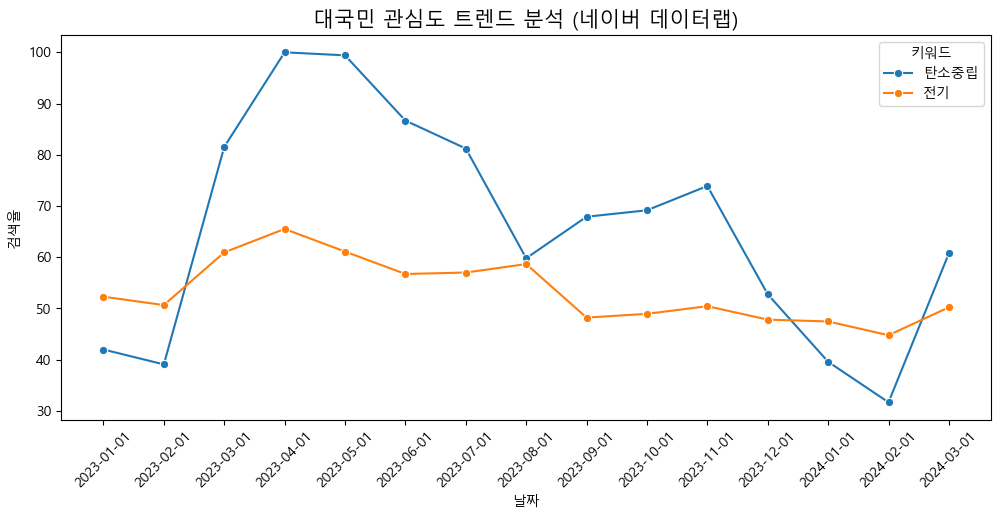

In [ ]:
#🟢네이버 키워드별 분석 - 탄소중립, 전기 
# 네이버 통합 검색어 트렌드 조회
import json
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 키 설정 (반드시 본인의 키를 넣으세요)
client_id = "FO94sqAIv4XrxJoV7qSf"
client_secret = "jfkOOP5NuM"

url = "https://openapi.naver.com/v1/datalab/search"
headers = {
    "X-Naver-Client-Id": client_id,
    "X-Naver-Client-Secret": client_secret,
    "Content-Type": "application/json"
}

# 2. 요청 데이터 설정
body = {
    "startDate": "2023-01-01",
    "endDate": "2024-03-31",
    "timeUnit": "month",
    "keywordGroups": [
        {"groupName": "탄소중립", "keywords": ["탄소중립", "넷제로"]},
        {"groupName": "전기", "keywords": ["전기", "절전"]}
        # {"groupName": "삼성", "keywords": ["삼성", "네이버"]}
    ]
}

#지정한 주소(url)로 POST 요청, url, headers 🍋서버에 보낼 '몸통(내용물)
response = requests.post(url, headers=headers, data=json.dumps(body))
res_data = response.json()#웹에서 가져온 데이터(JSON 형식)를 딕셔너리(dict)나 리스트(list)로 
# res_data #제이슨ppt18
# 3. 데이터가 정상적으로 왔는지 확인 후 처리
# 큰 박스(results) 안에 들어있는 작은 상자들(group)을 열어서, 
# 그 안의 내용물(i)에 이름표를 붙여 하나의 긴 줄(data_list)로 다시 세우는 것
if 'results' in res_data: #🍋제이슨에 results라는 키(Key) 존재?
    data_list = []
    for group in res_data['results']: #group이라는 변수에 results 그룹 상자 담기
        group_name = group['title'] #키워드 그룹을 변수에 저장
        for i in group['data']: #키워드 그룹 안에 들어 있는 날짜 데이터 하나씩 꺼내기
            data_list.append([i['period'], i['ratio'], group_name]) #이 형태로 묶기 # 날짜, 수치, 키워드 순으로 추가
    
    # 여기서 df_trend가 정의!
    df_trend = pd.DataFrame(data_list, columns=['날짜', '검색율', '키워드'])
    print("데이터 검색 키워드 수집 성공!")
    # print(df_trend) # 2️⃣내용 확인

    # 4. 🟠시각화 (데이터가 있을 때만 실행)
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.figure(figsize=(12, 5))

    sns.lineplot(data=df_trend, x='날짜', y='검색율', hue='키워드', marker='o') #시본
    
    plt.title('대국민 관심도 트렌드 분석 (네이버 데이터랩)', fontsize=15)
    plt.xticks(rotation=45)
    plt.show()
else:
    print("데이터 수집에 실패했습니다. 에러 내용을 확인하세요:")
    print(res_data) # 여기서 에러 원인을 확인해야 합니다.